# Problem Statement: Flight Delay Analysis & Characterization

### Context
Flight delays and cancellations present a major operational and financial challenge for airlines, airports, and passengers alike. Delays do not occur in isolation; they propagate through a network due to interconnected flight loops, tight turnaround windows, weather disruptions, and technical constraints. Understanding when, where, and why these delays happen is crucial for building robust schedule buffers and predictive models.

### Core Objective
The objective of this analysis is to perform Exploratory Data Analysis (EDA) on the flight dataset to uncover the underlying patterns, distributions, and root causes of departure and arrival delays. 

Specifically, this EDA aims to answer:
1. **Temporal Trends:** How do delays fluctuate across different days of the week, days of the month, or operational time windows?
2. **Geospatial & Carrier Impact:** Which airlines (Carriers) and origin airports/cities experience the highest frequency and severity of delays?
3. **Causal Attribution:** What are the primary breakdown drivers behind the total delay minutes (e.g., Carrier, Weather, National Airspace System (NAS), Security, or Late Arriving Aircraft)?
4. **Flight Characteristics:** Does flight distance or specific aircraft routes have a strong correlation with delay durations or cancellation rates?


# literature review

| Aspect | Paper 1 | Paper 2 |
|--------|---------|---------|
| **Title** | Statistical Characterization of Airplane Delays | A Review of Research on Flight Delay Propagation: Current Situation and Prospect |
| **Authors** | Mitsokapas, Schäfer, Harris, Beck | N. Li & H. G. Yao |
| **Source** | arXiv preprint, Queen Mary University of London (2021) | Journal of Advanced Transportation, Wiley (2025) |
| **What they studied** | Arrival delay patterns at 5 UK airports (2018–2020) | 641 research papers on delay spread (2014–2024) |
| **Main goal** | Understand *how* delays are distributed (early vs. late) | Review *methods* to predict and stop delay spreading |
| **Key finding #1** | Early arrivals drop fast (exponential); late arrivals drop slow (power-law) | Delays spread 2 ways: within airlines (shared crew/planes) & between airports (weather, congestion) |
| **Key finding #2** | Created 3 simple scores: mean delay, early-arrival rate, late-arrival risk | Simple models (basic ML) work for airline delays; complex models (deep learning) needed for airport-network delays |
| **Key finding #3** | COVID-19 reduced average delays, but extreme late flights still happened | Adding small buffer times in schedules helps block delay chains |
| **Key finding #4** | Heavy tails come from mixing many simple patterns (superstatistics) | Small airports are more vulnerable to delay impacts than big hubs |
| **Practical tip** | Don't just look at average delay—check extreme events too | Use real-time data + right model type = better predictions |


In [10]:
import pandas  as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✈️ Flight Dataset: Quick Column Reference Guide

### 📅 1. The Schedule (The Plan):
* **`DayOfWeek`** – The day of the week (`1` = Monday, `7` = Sunday).
* **`Origin_Airport`** – The 3-letter starting airport code (e.g., `BOS`, `LAX`).
* **`Origin_City_Name`** – Full city and state name where the flight took off.
* **`Scheduled_Departure`** – The time the plane was planned to leave the gate (24-hour format).
* **`Scheduled_Arrival`** – The time the plane was planned to land at its destination.
* **`Distance`** – The total trip distance measured in miles.
* **`Top_Carriers`** – A flag (`1` or `0`) marking whether the airline is a major industry giant.

---

### 🏁 2. Flight Metrics (The Reality)
* **`Departure_Time`** – The actual time the plane pushed back from the gate.
* **`Arrival_Time`** – The actual time the plane parked at the destination gate.
* **`Cancelled`** – A flag (`1` = Flight was called off, `0` = Flight flew).
* **`Diverted`** – A flag (`1` = Plane forced to land at a different airport, `0` = Normal landing).

---

### 🎯 3. The Performance (How Late Was It?)
* **`Dep_Delay`** – Departure delay in minutes (Positive = late, Negative = early).
* **`Arrival_Delay`** – Arrival delay in minutes (What matters most to passengers).
* **`Arr_Del_morethan15`** – Target flag (`1` = Late by 15+ minutes, `0` = On-time/Minor delay).

---

### 🔍 4. Causal Breakdown (Why Was It Late?)
*These numbers show exactly who is to blame if a flight is delayed 15+ minutes. For on-time flights, these are all `0`.*



* **`Carrier_Delay`** – **Airline Fault:** Mechanical breakdown, crew issues, late baggage loading, or cleaning.
* **`WeatherDelay`** – **Extreme Storms:** Blizzards, hurricanes, or severe weather conditions that make flying unsafe.
* **`NAS_Delay`** – **Airport Congestion:** Heavy air traffic control holds or long runway queues.
* **`Security_Delay`** – **Security Events:** TSA terminal backlogs, evacuations, or breaches (Very rare).
* **`Late_Aircraft_Delay`** – **The Domino Effect:** The plane arrived late from its *previous* flight, making this next flight start late.

### 🎯 Target Variable: `Arr_Del_morethan15` (The 15-Minute Rule)

In simple words, this column splits your data into a clear **Yes/No** question:
* **`0`** = **On-Time** (Arrived early, or late by 14 minutes or less).
* **`1`** = **Delayed** (Arrived late by 15 minutes or more).

---

### 🚀 Why This is the Absolute Best Target Variable

1. **Official Industry Standard:** The **FAA** does not count small 5-to-10 minute fluctuations as delays. A flight is only officially penalized and recorded as "delayed" when it crosses the **15-minute mark**.

Predicting exact minutes makes machine learning models perform poorly. Turning it into a **Binary (1 or 0)** problem fixes this distribution completely.

3. **High Business Value:** Crossing the 15-minute threshold is the exact point where things break: **passengers** start missing connecting flights, and **airlines** face penalties and broken crew schedules.

# hypothesis:
- bad weather leads to delay of the flight.
- leaving late results in reaching late.

In [11]:
df=pd.read_csv(r"D:\practice files\flight.csv")
df.head()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4821 entries, 0 to 4820
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   DayOfWeek            4821 non-null   int64
 1   Origin_Airport       4821 non-null   str  
 2   Scheduled_Departure  4821 non-null   int64
 3   Departure_Time       4821 non-null   int64
 4   Dep_Delay            4821 non-null   int64
 5   Scheduled_Arrival    4821 non-null   int64
 6   Arrival_Time         4821 non-null   int64
 7   Arrival_Delay        4821 non-null   int64
 8   Arr_Del_morethan15   4821 non-null   int64
 9   Cancelled            4821 non-null   int64
 10  Diverted             4821 non-null   int64
 11  Distance             4821 non-null   int64
 12  Carrier_Delay        4821 non-null   int64
 13  WeatherDelay         4821 non-null   int64
 14  NAS_Delay            4821 non-null   int64
 15  Security_Delay       4821 non-null   int64
 16  Late_Aircraft_Delay  4821 non-null 

- Numerical variables dominate the dataset.
- Delay-related columns will become highly important during analysis.

In [60]:
df.describe() 

,DayOfWeek,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
count,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.0,4821.0,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.0
mean,4.153703,1338.688032,1335.738021,22.082141,1502.412777,1468.282099,19.459863,0.322132,0.0,0.0,1549.053516,7.505497,1.382493,6.816013,0.051442,8.968056,1.0
std,2.007099,495.435065,524.024009,68.816913,562.241023,600.535851,71.904659,0.467342,0.0,0.0,914.825705,42.419294,19.499934,24.960025,1.524846,39.956099,0.0
min,1.000000,40.000000,1.000000,-20.000000,5.000000,1.000000,-58.000000,0.000000,0.0,0.0,187.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2.000000,900.000000,857.000000,-4.000000,1131.000000,1053.000000,-11.000000,0.000000,0.0,0.0,740.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,4.000000,1335.000000,1334.000000,0.000000,1549.000000,1538.000000,0.000000,0.000000,0.0,0.0,1438.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,6.000000,1725.000000,1751.000000,20.000000,1937.000000,1943.000000,25.000000,1.000000,0.0,0.0,2475.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,7.000000,2357.000000,2400.000000,1333.000000,2359.000000,2400.000000,1355.000000,1.000000,0.0,0.0,3784.000000,1189.000000,1010.000000,359.000000,68.000000,1333.000000,1.0


- seeing the missing values,skewed data through mean Vs median,the spread through the standard deviation,min and max to check out the outliers.

In [64]:
df.isnull().sum()

DayOfWeek              0
Origin_Airport         0
Scheduled_Departure    0
Departure_Time         0
Dep_Delay              0
Scheduled_Arrival      0
Arrival_Time           0
Arrival_Delay          0
Arr_Del_morethan15     0
Cancelled              0
Diverted               0
Distance               0
Carrier_Delay          0
WeatherDelay           0
NAS_Delay              0
Security_Delay         0
Late_Aircraft_Delay    0
Top_Carriers           0
dtype: int64

**no null values found in this dataset**

In [66]:
df.duplicated().sum()

np.int64(8)

In [71]:
# 8 duplicates rows found

In [70]:
df[df.duplicated(keep=False)]

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
88,2,JFK,1245,1242,-3,1545,1516,-29,0,0,0,2475,0,0,0,0,0,1
102,2,JFK,1245,1242,-3,1545,1516,-29,0,0,0,2475,0,0,0,0,0,1
971,3,LAX,750,745,-5,1401,1345,-16,0,0,0,1744,0,0,0,0,0,1
978,3,LAX,750,745,-5,1401,1345,-16,0,0,0,1744,0,0,0,0,0,1
1565,5,ORD,2020,2017,-3,2243,2236,-7,0,0,0,1739,0,0,0,0,0,1
1581,5,ORD,2020,2017,-3,2243,2236,-7,0,0,0,1739,0,0,0,0,0,1
1633,1,ORD,2210,2214,4,30,25,-5,0,0,0,802,0,0,0,0,0,1
1638,1,ORD,2210,2214,4,30,25,-5,0,0,0,802,0,0,0,0,0,1
2528,5,DFW,720,720,0,901,853,-8,0,0,0,1464,0,0,0,0,0,1
2542,5,DFW,720,720,0,901,853,-8,0,0,0,1464,0,0,0,0,0,1


In [116]:
df[df['Arrival_Delay']>15]

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers,Total_Delay,Delay_Category
11,4,BOS,600,640,40,711,752,41,1,0,0,187,40,0,1,0,0,1,81,Moderate Delay
17,4,BOS,600,745,105,711,858,107,1,0,0,187,105,0,2,0,0,1,212,Heavy Delay
19,6,BOS,600,621,21,711,740,29,1,0,0,187,21,0,8,0,0,1,50,Moderate Delay
23,6,BOS,600,648,48,711,821,70,1,0,0,187,48,0,22,0,0,1,118,Heavy Delay
24,5,JFK,830,846,16,1138,1200,22,1,0,0,2475,0,0,6,0,16,1,38,Moderate Delay
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4810,5,LAX,815,1309,294,1652,2136,284,1,0,0,2611,284,0,0,0,0,1,578,Heavy Delay
4812,7,LAX,815,1033,138,1652,1855,123,1,0,0,2611,123,0,0,0,0,1,261,Heavy Delay
4816,4,LAX,815,845,30,1652,1728,36,1,0,0,2611,30,0,6,0,0,1,66,Moderate Delay
4819,1,LAX,815,811,-4,1652,1709,17,1,0,0,2611,0,0,17,0,0,1,13,Moderate Delay


In [72]:
# removing the duplicates
df.drop_duplicates(inplace=True)

In [73]:
# checking if the duplicates have been removed or not 
df.duplicated().sum()

np.int64(0)

# FEATURE ENGINEERING

In [12]:
df['Total_Delay'] = (df['Dep_Delay'] +df['Arrival_Delay'])

# Total_Delay shows the combined delay impact per flight.

In [13]:
df['Delay_Category'] = pd.cut(
    df['Arrival_Delay'],

    bins=[-100,-1,15,60,500],

    labels=[
        'Early',
        'Minor Delay',
        'Moderate Delay',
        'Heavy Delay'
    ]
)

# Delay segmentation improves business interpretation.

In [14]:
# creating a target variable:

df['Arrival_Delay_15_Min'] = (
    df['Arrival_Delay'] > 15
).astype(int)

df['Arrival_Delay_15_Min_Label'] = (
    df['Arrival_Delay_15_Min']
    .map({
        0:'On Time',
        1:'Delayed (>15 Min)'
    })
)

In [166]:
df.sample(3)

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,...,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers,Total_Delay,Delay_Category,Arrival_Delay_15_Min,Arrival_Delay_15_Min_Label
631,6,LAX,1430,1527,57,2304,2350,46,1,0,...,0,0,46,0,0,1,103,Moderate Delay,1,Delayed (>15 Min)
3952,4,ORD,1514,1706,112,1850,2053,123,1,0,...,47,0,11,0,65,1,235,Heavy Delay,1,Delayed (>15 Min)
3575,1,LAX,600,555,-5,1434,1411,-23,0,0,...,0,0,0,0,0,1,-28,Early,0,On Time


# univariate analysis:

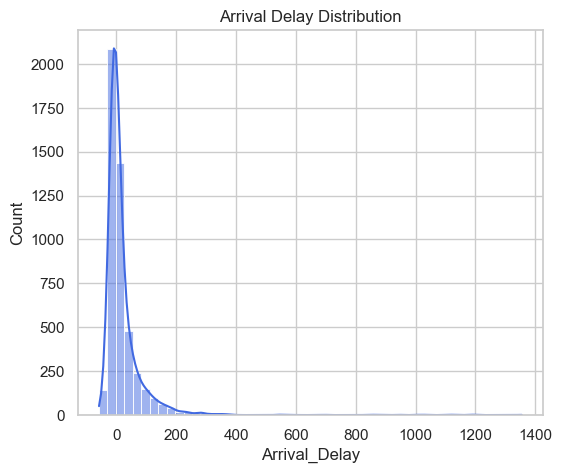

In [167]:
plt.figure(figsize=(6,5))

sns.histplot(
    df['Arrival_Delay'],

    bins=50,
    kde=True,

    color='royalblue'
)

plt.title('Arrival Delay Distribution')

plt.show()

- Most flights are concentrated around low delay ranges.
- Extreme delay cases exist but occur less frequently.
- Flight operations remain relatively stable for most trips.

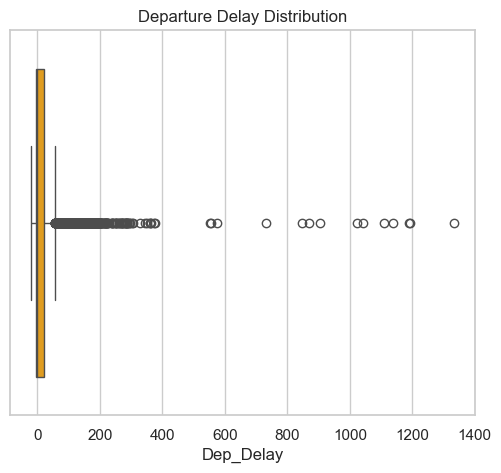

In [168]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x=df['Dep_Delay'],

    color='orange'
)

plt.title('Departure Delay Distribution')

plt.show()

- Most flights depart close to scheduled time.
- Several large departure outliers indicate operational disruptions.
- Some flights experience severe departure instability.

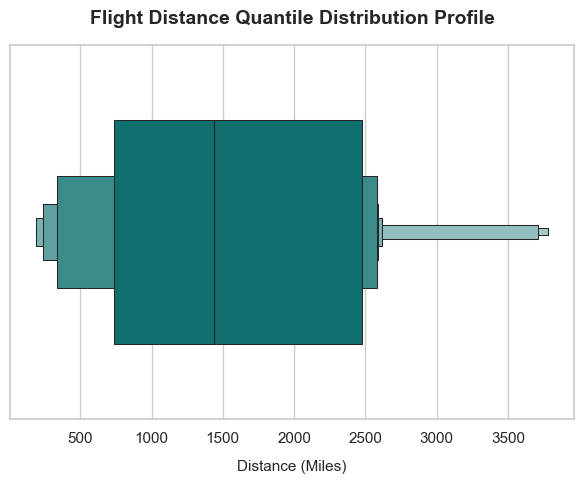

In [169]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))


sns.boxenplot(
    data=df,
    x='Distance',
    color='teal',       
    width=0.6,         
    showfliers=True    
)

plt.title('Flight Distance Quantile Distribution Profile', fontsize=14, pad=15, weight='bold')
plt.xlabel('Distance (Miles)', fontsize=11, labelpad=10)

# Clean up layout and display
plt.tight_layout()
plt.show()

- Most flights are standard, middle-distance trips between 750 and 2,500 miles. The exact middle is 1,450 miles.

- Flights cut off quickly below 500 miles. This means the company rarely flies very short distances.

- Trips over 2,500 miles are rare, but they stretch out slowly in steps all the way to 3,800 miles.

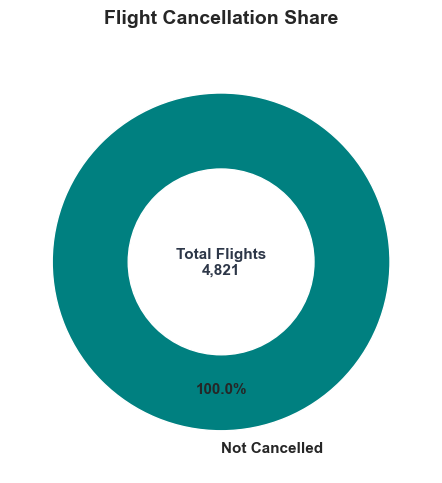

In [170]:
import matplotlib.pyplot as plt
import seaborn as sns


cancel_counts = df['Cancelled'].value_counts()


sns.set_theme(style="white")
plt.figure(figsize=(5, 5))


all_labels = ['Not Cancelled', 'Cancelled']
dynamic_labels = all_labels[:len(cancel_counts)] 

colors = ['teal', 'coral']


plt.pie(
    cancel_counts.values, 
    labels=dynamic_labels, 
    autopct='%1.1f%%',         
    startangle=90,             
    colors=colors[:len(cancel_counts)],
    pctdistance=0.75,          
    textprops={'fontsize': 11, 'weight': 'bold'}
)


centre_circle = plt.Circle((0,0), 0.55, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)


total_flights = cancel_counts.sum()
plt.text(
    0, 0, f"Total Flights\n{total_flights:,}", 
    ha='center', va='center', fontsize=11, weight='bold', color='#2d3748'
)

plt.title('Flight Cancellation Share', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.show()

In [171]:
df['Cancelled'].describe()

count    4821.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Cancelled, dtype: float64

- all  flights are completed successfully.
- Airline operations show strong completion efficiency overall.

C:\Users\Asus\AppData\Local\Temp\ipykernel_19720\2277123214.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


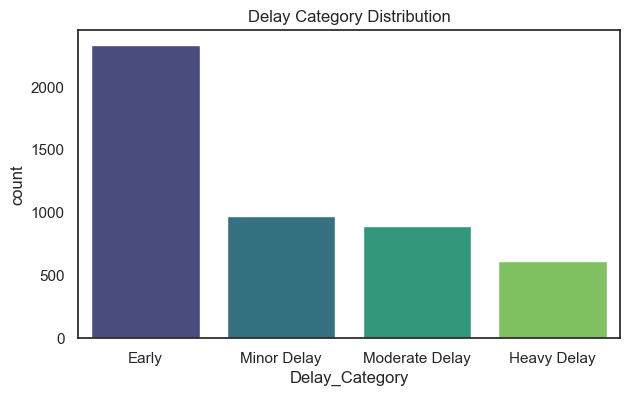

In [172]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,

    x='Delay_Category',

    palette='viridis'
)

plt.title('Delay Category Distribution')

plt.show()

In [173]:
df.groupby('Delay_Category')['Arrival_Delay'].agg(['mean','count','std'])

,mean,count,std
Delay_Category,,,
Early,-13.392291,2335,9.276960
Minor Delay,6.658084,971,4.447226
Moderate Delay,33.006734,891,12.855636
Heavy Delay,124.895082,610,63.084082


- most flights are before the arrival time,which is good and shows efficiency of that particular flight,also it provide a satisfactory experience to the customers.
- Mean = 124.9 , On an average  heavy delays are 2 hours.
-  Std Dev = 63.1 min → But actual delays vary widely — from ~1 hour to 3+ hours.
-  Big picture: Heavy delays are frequent, severe, and unpredictable — requiring robust operational strategies, not just average-based planning.
   

# Bivariate analysis:

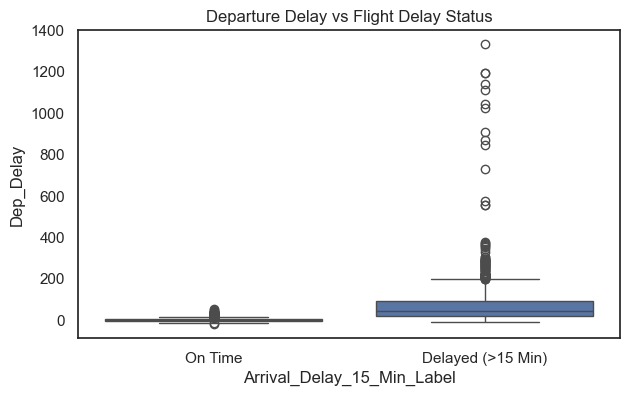

In [174]:
plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,

    x='Arrival_Delay_15_Min_Label',
    y='Dep_Delay'
)

plt.title(
    'Departure Delay vs Flight Delay Status'
)

plt.show()

- Flights delayed at departure are much more likely to become delayed arrivals.
- Departure delay is the strongest operational warning sign.
- Airlines struggle to recover once a flight leaves late.

Departure Delay is the Ultimate Predictor: If a flight leaves late, it almost always arrives late. The "Delayed" box sits significantly higher on the chart than the "On Time" box.

The "Point of No Return" (~20 Minutes): Look closely at the "On Time" box—its maximum limit (the top whisker) cuts off very low, close to 15–20 minutes. This means if a plane is delayed at departure by more than 20 minutes, it is practically impossible for it to catch up in the air and land on time.

The Extreme Outliers (Operational Nightmares): The long trail of dots stretching up to 1,400 minutes (nearly 24 hours!) on the delayed side highlights severe operational breakdowns. These are rare but massive disruptions (like major mechanical failures or grounding tech issues) that distort the entire schedule.

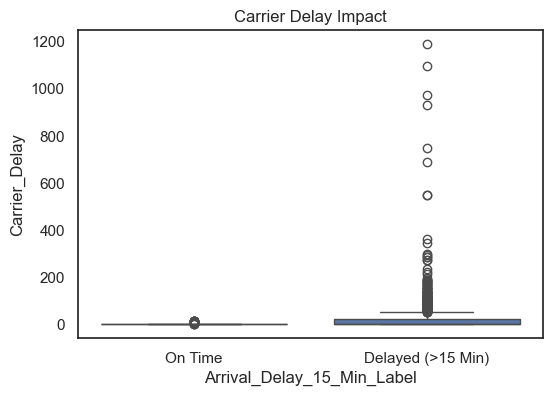

In [175]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,

    x='Arrival_Delay_15_Min_Label',
    y='Carrier_Delay'
)

plt.title(
    'Carrier Delay Impact'
)

plt.show()

- Delayed flights show significantly higher carrier-related delays.
- Airline operational efficiency directly impacts punctuality.
- Internal airline issues contribute heavily to delays.

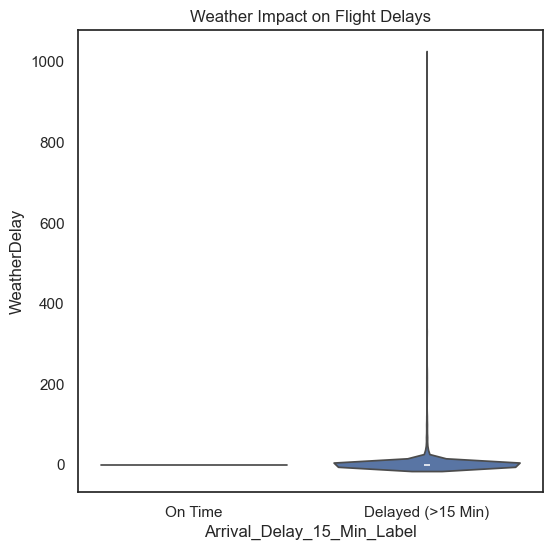

In [176]:
plt.figure(figsize=(6,6))

sns.violinplot(
    data=df,

    x='Arrival_Delay_15_Min_Label',
    y='WeatherDelay'
)

plt.title(
    'Weather Impact on Flight Delays'
)

plt.show()

- Most on-time flights experience little or no weather disruption.
- Weather becomes a major contributor in delayed flights.
- Severe weather dramatically increases delay probability.

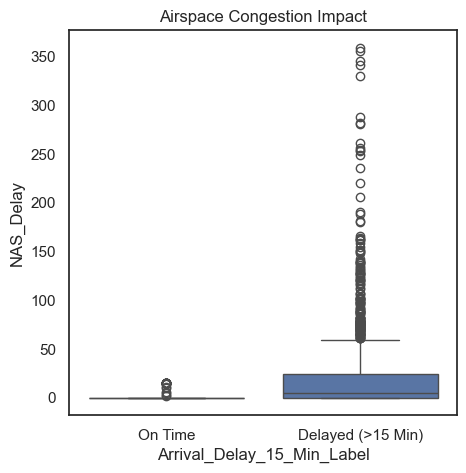

In [177]:
plt.figure(figsize=(5,5))

sns.boxplot(
    data=df,

    x='Arrival_Delay_15_Min_Label',
    y='NAS_Delay'
)

plt.title(
    'Airspace Congestion Impact'
)

plt.show()

- nas delay(Airport Congestion):
- Delayed flights show higher NAS delays.
- Air traffic congestion creates system-wide delay effects.
- Congested airspace reduces schedule reliability

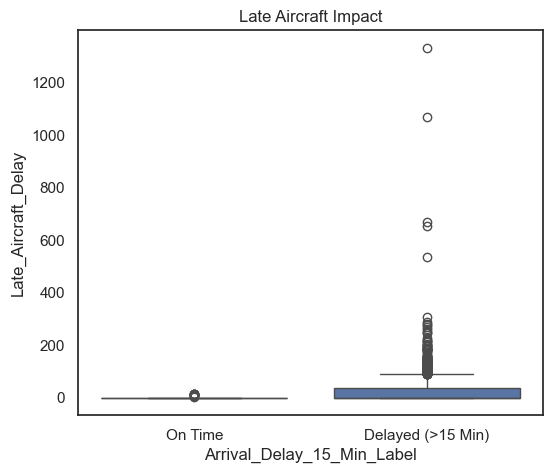

In [178]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,

    x='Arrival_Delay_15_Min_Label',
    y='Late_Aircraft_Delay'
)

plt.title(
    'Late Aircraft Impact'
)

plt.show()

- The Domino Effect: When a plane arrives late for one flight, it doesn't have enough time to prepare, so its very next flight is forced to take off late too.

- This "pass-the-delay" pattern is one of the absolute biggest headaches for airlines because once a delay starts, it gets trapped in the schedule and is incredibly hard to stop.

- The Chain Reaction: A single broken link ruins the chain. One messed-up flight morning can trigger a massive chain reaction that ruins 4 or 5 other flights later in the day.

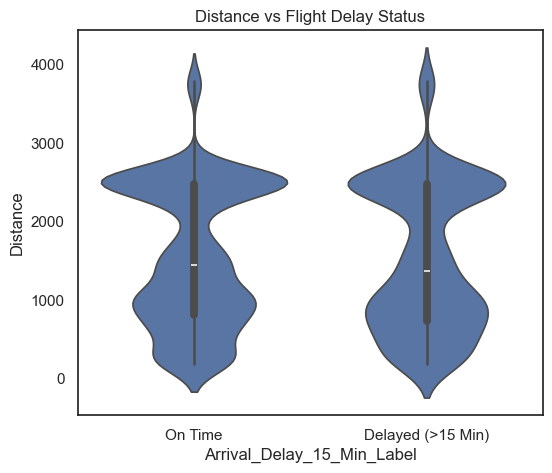

In [179]:
plt.figure(figsize=(6,5))

sns.violinplot(
    data=df,

    x='Arrival_Delay_15_Min_Label',
    y='Distance'
)

plt.title(
    'Distance vs Flight Delay Status'
)

plt.show()

- Flight distance alone is not a strong delay driver.
- Both short and long flights experience delays.
- Operational factors matter more than route len

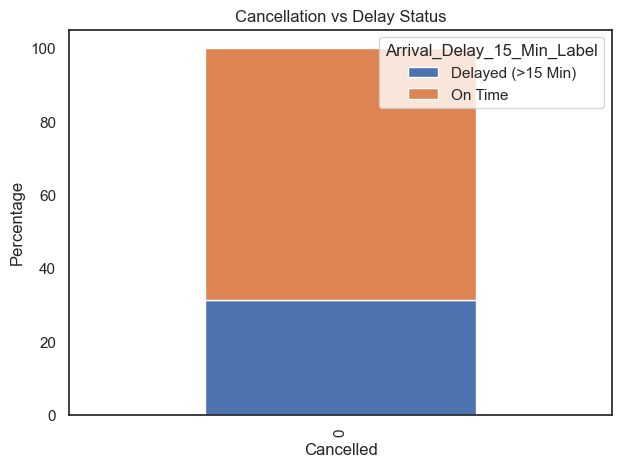

In [181]:
cancel_delay = pd.crosstab(
    df['Cancelled'],
    df['Arrival_Delay_15_Min_Label'],
    normalize='index'
)*100

cancel_delay.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title(
    'Cancellation vs Delay Status'
)

plt.ylabel('Percentage')

plt.show()

**Cancelled – A flag (1 = Flight was called off, 0 = Flight flew)**

- It Only Shows Completed Flights: Because the X-axis is stuck on 0 (Not Canceled), this chart is exclusively looking at flights that successfully took off and landed.

- For these completed flights, about 32% were delayed (blue) and 68% were on time (orange). That means roughly 1 out of every 3 flights you take in this dataset lands late.

- There is no bar for 1 (Canceled flights). This is because a flight that gets canceled never actually arrives at its destination, so it cannot have an "arrival delay" value. They are completely excluded from this visual.

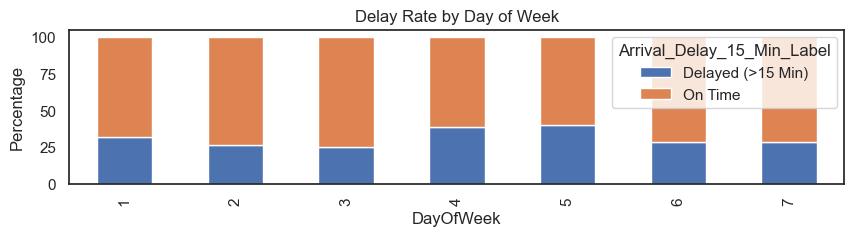

In [182]:
day_delay = pd.crosstab(
    df['DayOfWeek'],
    df['Arrival_Delay_15_Min_Label'],
    normalize='index'
)*100

day_delay.plot(
    kind='bar',
    stacked=True,
    figsize=(10,2)
)

plt.title(
    'Delay Rate by Day of Week'
)

plt.ylabel('Percentage')

plt.show()

- Delay probability changes across the week.
- Some days experience heavier operational load.
- Weekly traffic patterns influence punctuality.

# MULTIVARIATE ANALYSIS:

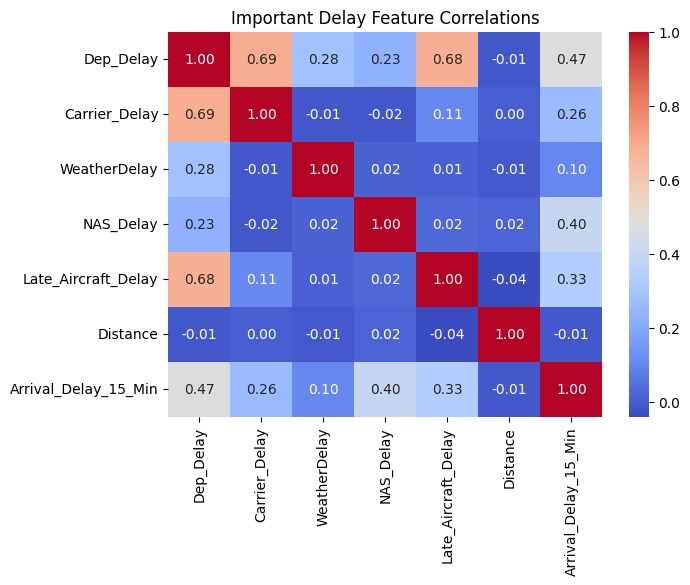

In [18]:
encoded_df = df.copy()

encoded_df['Arrival_Delay_15_Min'] = (
    encoded_df['Arrival_Delay'] > 15
).astype(int)

important_cols = [
    'Dep_Delay',
    'Carrier_Delay',
    'WeatherDelay',
    'NAS_Delay',
    'Late_Aircraft_Delay',
    'Distance',
    'Arrival_Delay_15_Min'
]

plt.figure(figsize=(7,5))

sns.heatmap(
    encoded_df[important_cols].corr(),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'
)

plt.title(
    'Important Delay Feature Correlations'
)

plt.show()

- Departure is King (0.47): Leaving late is the number one reason a flight arrives late.

- The Domino Effect (0.68): An incoming plane arriving late instantly affects the next flight's departure time.

- Airline Blame (0.69): Carrier issues (like broken planes or crew shortages) are the absolute biggest cause of gate delays.

- Traffic Jams (0.40): Airport and air traffic control congestion (NAS_Delay) heavily drive final arrival delays.

- Distance Doesn't Matter (-0.01): Whether a flight is 200 miles or 2,000 miles long has zero impact on delays.

- Weather is Rare (0.10): Major storms cause massive headlines, but day-to-day, weather is not the main driver of delays across the network.(Hypothesis rejected as not so strong relation.)

<Figure size 300x300 with 0 Axes>

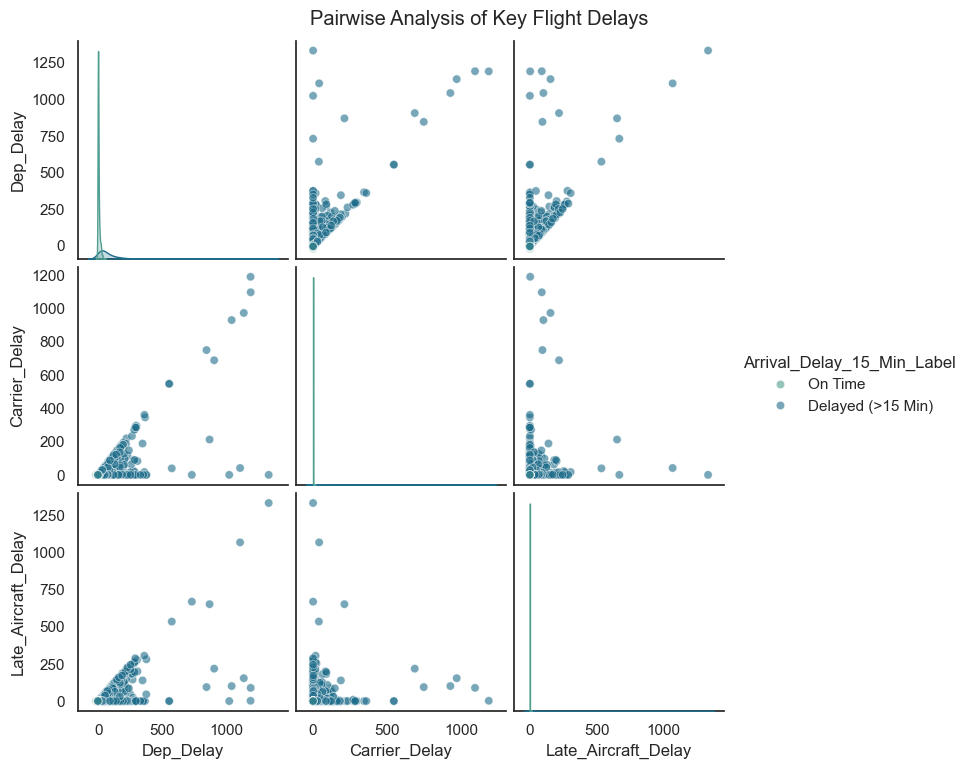

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt
columns_to_plot = ['Dep_Delay', 'Carrier_Delay', 'Late_Aircraft_Delay', 'Arrival_Delay_15_Min_Label']
plt.figure(figsize=(3, 3))
sns.pairplot(
    data=df[columns_to_plot], 
    hue='Arrival_Delay_15_Min_Label', 
    palette='crest',
    diag_kind='kde', 
    plot_kws={'alpha': 0.6} 
)

plt.suptitle('Pairwise Analysis of Key Flight Delays', y=1.02)
plt.show()

-  Whenever carrier or late aircraft problems go up, total departure delays shoot straight up too.

- Look at the bottom-left corners near 0. All the "On Time" flights are trapped here. If there are no airline or late plane issues, the flight is almost always on time.

- Notice the "L-shape" in the chart comparing Carrier Delay and Late Aircraft Delay. They rarely happen together. A flight is usually ruined by either a broken plane or a late incoming flight—almost never both at the same time.

- The smooth mountain lines on the diagonal show that for most flights, these delay numbers sit exactly at 0. Delays don't happen to every flight, but when they do hit, they hit hard.

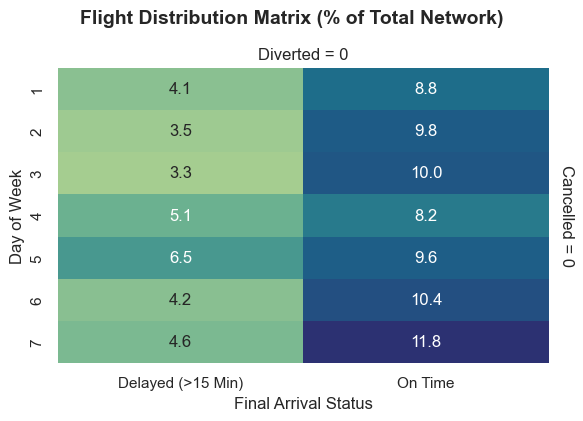

In [194]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

pivot_data = pd.crosstab(
    index=df['DayOfWeek'], 
    columns=[df['Cancelled'], df['Diverted'], df['Arrival_Delay_15_Min_Label']],
    normalize='all'
) * 100

df_heatmap = pivot_data.stack([0, 1, 2]).reset_index(name='Percentage')

g = sns.FacetGrid(
    df_heatmap, 
    row='Cancelled', 
    col='Diverted', 
    margin_titles=True, 
    height=4, 
    aspect=1.5
)

def draw_heatmap(*args, **kwargs):
    data = kwargs.pop('data')
    local_pivot = data.pivot(index='DayOfWeek', columns='Arrival_Delay_15_Min_Label', values='Percentage')
    sns.heatmap(local_pivot, annot=True, fmt=".1f", cmap='crest', cbar=False, **kwargs)

g.map_dataframe(draw_heatmap)

g.set_axis_labels("Final Arrival Status", "Day of Week")
plt.suptitle('Flight Distribution Matrix (% of Total Network)', y=1.05, fontsize=14, fontweight='bold')
plt.show()

**The Most Common Outcome:** The dark blue column on the right shows that the vast majority of flights run completely On Time across every single day of the week.

**The Worst Day for Delays:** Look at Day 5 (Friday). It has the highest delay percentage (6.5%), making it the trickiest day of the week to travel.

**The Smoothest Travel Days:** Days 2 and 3 (Tuesday and Wednesday) have the lowest delay numbers (3.5% and 3.3%), meaning mid-week is your safest bet to avoid waiting.

**The Busiest On-Time Day:** Day 7 (Sunday) holds the single highest score on the entire chart (11.8% running on time), showing a massive volume of successful weekend flights.

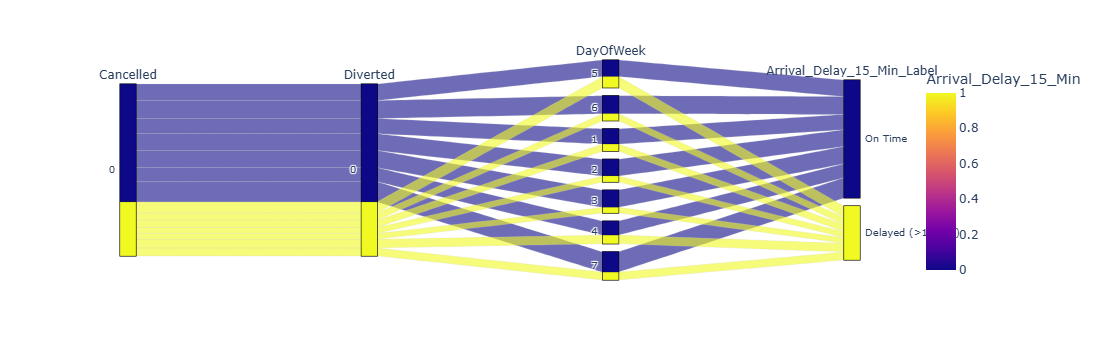

In [15]:
import plotly.express as px
fig = px.parallel_categories(
    df,

    dimensions=[
        'Cancelled',
        'Diverted',
        'DayOfWeek',
        'Arrival_Delay_15_Min_Label'
    ],

    color='Arrival_Delay_15_Min'
)

fig.show()

- Virtually all flights start at Not Cancelled (0) and flow directly into Not Diverted (0). This is the massive, healthy master stream of your data.
-  From that main stream, the traffic branches out evenly across all days of the week, but Day 5 (Friday) handles a noticeably thicker stream of flights.
-  The Blue Chain: Flights that stay on the dark blue path sail straight through the week and finish cleanly as On Time.
- Flights that drop into the bright yellow path get caught up in operational issues during the week and always end up Delayed.
- If you follow the yellow paths backward from the "Delayed" block, a disproportionately thick yellow strand links right back to Day 5 (Friday).

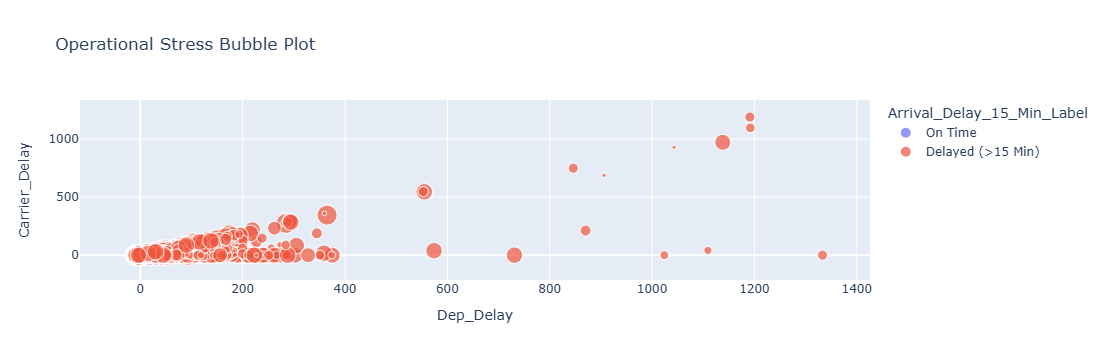

In [16]:
fig = px.scatter(
    df,

    x='Dep_Delay',
    y='Carrier_Delay',

    size='Distance',

    color='Arrival_Delay_15_Min_Label',

    title='Operational Stress Bubble Plot'
)

fig.show()

- The chart is entirely flooded with red bubbles. This means once a flight hits these higher departure or carrier delay numbers, it is 100% guaranteed to be Delayed.

- The Escalation Path: There is a clear upward trend from left to right. As Carrier_Delay climbs toward 500+ minutes, Dep_Delay naturally scales right along with it, creating massive extreme outliers past the 1,000-minute mark.

- Hidden Traps (The Bottom Line): Notice the large red bubbles sitting right on the bottom 0 line of Carrier Delay, even out past 1,200 minutes of Departure Delay. This proves a flight can face massive, day-ruining departure delays even when the carrier itself has zero technical issues (likely caused by weather or late incoming aircraft instead).

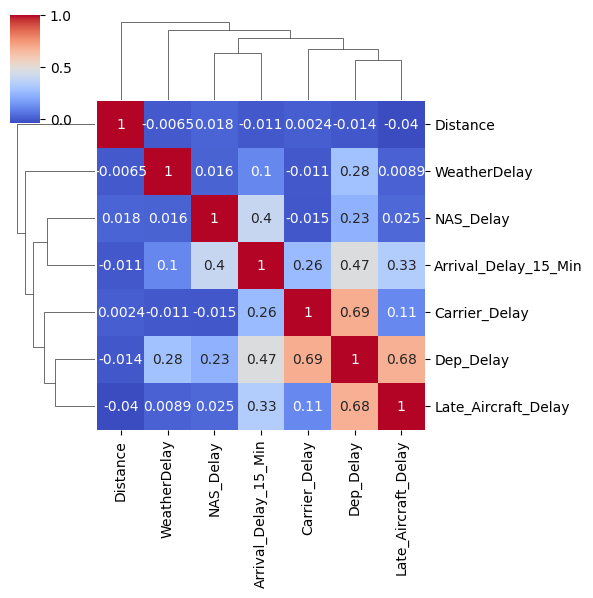

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.clustermap(
    encoded_df[important_cols].corr(),
    annot=True,
    cmap='coolwarm',
    figsize=(6, 6)
)

plt.show()

- Dep_Delay (Departure Delay) has a strong orange connection with both Carrier_Delay and Late_Aircraft_Delay. This means airline issues and late incoming planes are the primary drivers that push departure delays up.

- The Best Predictor (0.47): If you want to know if a flight will land late (Arrival_Delay_15_Min), look at Dep_Delay. It has the highest correlation score with actual arrival delays.

- The Connected Cluster: The tree lines group Carrier Delay, Departure Delay, and Late Aircraft Delay closely together at the bottom right. They act like a domino effect—one usually triggers the others.

- The Myth Buster (-0.04): Distance has a blue, near-zero connection with everything. Long flights are no more likely to be delayed than short flights. Distance has no impact on operational stress.

# Flight Delay Dataset - Complete EDA Report

## Executive Summary

The objective of this analysis was to understand the factors that cause a flight to arrive more than 15 minutes late.

Instead of analyzing the exact arrival delay minutes, the analysis focused on a business-friendly target:

**Delayed Flight = Arrival Delay > 15 Minutes**

This helps identify which operational factors increase the probability of a significant flight delay.

The analysis included data cleaning, feature engineering, univariate analysis, bivariate analysis, and multivariate analysis to uncover the most important delay drivers.



# Data Quality Assessment

The dataset was first checked for:

* Missing values
* Duplicate records
* Incorrect data types
* Outliers

Duplicate records were removed and missing values were checked.

This ensured that the analysis was based on clean and reliable data.


## Correlation Analysis

The strongest relationships were observed between:

* Departure Delay
* Late Aircraft Delay
* Arrival Delay > 15 Minutes

Weather and NAS delays also showed meaningful contributions.

### Key Insight

Flight delays are usually caused by multiple factors working together.

# Key Business Findings

The five strongest drivers of flight delays are:

1. Departure Delay
2. Late Aircraft Delay
3. Carrier Delay
4. NAS Delay
5. Weather Delay

These variables consistently showed the strongest relationship with flights arriving more than 15 minutes late.

---

# Operational Recommendations

### Reduce Departure Delays

Since departure delay is the strongest predictor of arrival delay, airlines should prioritize on-time departures.

### Improve Aircraft Rotation Planning

Late arriving aircraft create delay chains.

Better scheduling can reduce these cascading(one event triggering another event ) effects.

### Reduce Airspace Congestion

Better traffic management can help reduce NAS-related delays.

# Final Conclusion

The analysis shows that flights arriving more than 15 minutes late are usually not caused by a single factor.

Instead, delays are the result of multiple operational issues occurring together.

Among all variables, Departure Delay emerged as the most influential factor.

Late Aircraft Delay, Carrier Delay, Weather Delay, and NAS Delay further increase the likelihood of a delayed arrival.

Overall, airline operations appear stable for most flights, but when disruptions occur, they often create chain reactions that affect multiple flights across the network.

The findings suggest that improving departure punctuality and reducing delay propagation would have the greatest impact on improving overall airline performance and reducing significant arrival delays.
